In [1]:
# https://judge.nitro-ai.org/competitions/nitro/rise-2026-final/1/view

import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import json
import torch 
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from IPython.display import clear_output

In [2]:
task1_corpus_json = '/kaggle/input/datasets/abukanabek/rise-final-round-2026-false-friends/train_data/train_data/task1_corpus.json'
task1_train_queries_json = '/kaggle/input/datasets/abukanabek/rise-final-round-2026-false-friends/train_data/train_data/task1_train_queries.json'
task1_test_queries_json = '/kaggle/input/datasets/abukanabek/rise-final-round-2026-false-friends/test_data/task1_test_queries.json'

with open(task1_corpus_json, 'r') as f:
    corpus = pd.DataFrame(json.load(f))
    corpus['doc_id'] = corpus['doc_id'].map(lambda x: int(x.split('_')[-1])-1)

with open(task1_train_queries_json, 'r') as f:
    train = pd.DataFrame(json.load(f)).rename(columns={'correct_doc_id': 'doc_id'})
    train['doc_id'] = train['doc_id'].map(lambda x: int(x.split('_')[-1])-1)

with open(task1_test_queries_json, 'r') as f:
    test = pd.DataFrame(json.load(f))

train = pd.merge(left=train, right=corpus, on='doc_id')

corpus.shape, train.shape, test.shape

((15000, 2), (5000, 5), (1500, 3))

In [3]:
corpus.head()

,doc_id,text
0,0,Aaah!! Calculatorul meu s-a stricat!
1,1,Accidentul s-a produs dintr-o simplă greșeală.
2,2,Această bere conţine 5 % alcool.
3,3,Această clădire veche nu merită să fie reparat...
4,4,Aceasta este casa lui Tom.


In [4]:
train.head()

,query_id,query_language,query_text,doc_id,text
0,q_train_00000,es,¿Sois de Urumqi?,1390,Sunteţi din Urumqi?
1,q_train_00001,es,Hay una televisión en mi habitación.,699,Există un televizor în camera mea.
2,q_train_00002,es,Tom ha estado en el corredor de la muerte dura...,1514,Tom e pe culoarul morții de trei ani.
3,q_train_00003,es,No tengo ganas.,1026,Nu am chef.
4,q_train_00004,es,Daniela me llamó a casa.,438,Daniela mi-a telefonat acasă.


In [5]:
train['query_language'].value_counts()

query_language
es    3036
pt    1964
Name: count, dtype: int64

In [6]:
test['query_language'].value_counts()

query_language
es    877
pt    623
Name: count, dtype: int64

In [7]:
(train['text'].str[-1] == train['query_text'].str[-1]).mean()

np.float64(0.9904)

In [8]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")
model.device

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

device(type='cuda', index=0)

In [9]:
def get_embeddings(sentences, batch_size=32):
    embs = []
    for i in tqdm(range(0, len(sentences), batch_size)):
        batch_embs = model.encode(sentences[i:min(i+batch_size, len(sentences))])
        embs.append(batch_embs)
    embs = np.concatenate(embs)
    return embs

corpus_embeddings = get_embeddings(corpus['text'].tolist())
train_embeddings = get_embeddings(train['query_text'].tolist())
test_embeddings = get_embeddings(test['query_text'].tolist())
corpus_embeddings.shape, train_embeddings.shape, test_embeddings.shape

  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

((15000, 768), (5000, 768), (1500, 768))

In [10]:
def np_cosine_similarity(x1, x2):
    return (x1 / np.linalg.norm(x1, axis=1, ord=2)[:, None]) @ (x2 / np.linalg.norm(x2, axis=1, ord=2)[:, None]).T

sim = np_cosine_similarity(train_embeddings, corpus_embeddings)
sim.shape

(5000, 15000)

In [11]:
(sim.argmax(axis=1) == train['doc_id']).mean()

np.float64(0.8886)

In [12]:
es_indices_train = np.where(train['query_language'] == 'es')[0]
pt_indices_train = np.where(train['query_language'] == 'pt')[0]

es_indices_test = np.where(test['query_language'] == 'es')[0]
pt_indices_test = np.where(test['query_language'] == 'pt')[0]

es_indices_train.shape, pt_indices_train.shape, es_indices_test.shape, pt_indices_test.shape

((3036,), (1964,), (877,), (623,))

In [13]:
sim_es = np_cosine_similarity(train_embeddings[es_indices_train], corpus_embeddings)
sim_pt = np_cosine_similarity(train_embeddings[pt_indices_train], corpus_embeddings)
sim_es.shape, sim_pt.shape

((3036, 15000), (1964, 15000))

In [14]:
(sim_es.argmax(axis=1) == train['doc_id'][es_indices_train]).mean(), (sim_pt.argmax(axis=1) == train['doc_id'][pt_indices_train]).mean()

(np.float64(0.8906455862977603), np.float64(0.8854378818737271))

In [15]:
class EmbeddingDataset(nn.Module):
    def __init__(self, embs1, embs2):
        self.embs1 = embs1
        self.embs2 = embs2

    def __len__(self):
        return len(self.embs1)

    def __getitem__(self, idx):
        return torch.tensor(self.embs1[idx]), torch.tensor(self.embs2[idx])

es_train_ds = EmbeddingDataset(train_embeddings[es_indices_train], corpus_embeddings[train['doc_id'][es_indices_train]])
pt_train_ds = EmbeddingDataset(train_embeddings[pt_indices_train], corpus_embeddings[train['doc_id'][pt_indices_train]])

train_proportion = 0.9
val_proportion = 0.1

generator = torch.Generator().manual_seed(42)
es_train_ds, es_valid_ds = random_split(
    es_train_ds, 
    [train_proportion, val_proportion],
    generator=generator
)

generator = torch.Generator().manual_seed(24)
pt_train_ds, pt_valid_ds = random_split(
    pt_train_ds, 
    [train_proportion, val_proportion],
    generator=generator
)

BATCH_SIZE = 32

es_train_loader = DataLoader(es_train_ds, batch_size=BATCH_SIZE, shuffle=True)
es_valid_loader = DataLoader(es_valid_ds, batch_size=BATCH_SIZE, shuffle=False)

pt_train_loader = DataLoader(pt_train_ds, batch_size=BATCH_SIZE, shuffle=True)
pt_valid_loader = DataLoader(pt_valid_ds, batch_size=BATCH_SIZE, shuffle=False)

len(es_train_loader), len(es_valid_loader), len(pt_train_loader), len(pt_valid_loader)

(86, 10, 56, 7)

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [17]:
class ProjectionHead(nn.Module):
    def __init__(self, emb_size=768, proj_size=256):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(emb_size, proj_size)
        )
        
    def forward(self, x):
        return self.head(x)

class InfoNCELoss(nn.Module):
    def __init__(self, temperature=0.2):
        super().__init__()
        self.temperature = temperature

    def forward(self, x, y):
        B, D = x.shape
        sim = F.normalize(x) @ F.normalize(y).T
        sim = sim / self.temperature
        labels = torch.arange(B, device=x.device)
        loss = (
            F.cross_entropy(sim, labels) + 
            F.cross_entropy(sim.T, labels)
        ) / 2
        return loss

In [18]:
def fit_one_epoch(projectors, optimizers, criterion, train_loader, device):
    projectors['source'].train()
    projectors['target'].train()
    total, rloss = 0, 0
    
    for source, target in (pbar := tqdm(train_loader, desc='Train Loader', leave=False)):
        batch_size = len(source)
        source, target = source.to(device), target.to(device)
        proj_source, proj_target = projectors['source'](source), projectors['target'](target)
        loss = criterion(proj_source, proj_target)

        optimizers['source'].zero_grad()
        optimizers['target'].zero_grad()
        loss.backward()
        optimizers['source'].step()
        optimizers['target'].step()

        total += batch_size
        rloss += loss.item() * batch_size
        cur_loss = rloss / total
        pbar.set_postfix({'loss': f'{cur_loss:.6f}'})
        
    return cur_loss

@torch.no_grad()
def eval_one_epoch(projectors, criterion, valid_loader, device):
    projectors['source'].eval()
    projectors['target'].eval()
    total, rloss = 0, 0
    
    for source, target in (pbar := tqdm(valid_loader, desc='Valid Loader', leave=False)):
        batch_size = len(source)
        source, target = source.to(device), target.to(device)
        proj_source, proj_target = projectors['source'](source), projectors['target'](target)
        loss = criterion(proj_source, proj_target)
        total += batch_size
        rloss += loss.item() * batch_size
        cur_loss = rloss / total
        pbar.set_postfix({'loss': f'{cur_loss:.6f}'})
        
    return cur_loss

def plot_progress(history, plot_title):
    clear_output(wait=True)
    plt.figure(figsize=(15, 5))
    plt.suptitle(plot_title)
    plt.subplot(1, 1, 1)
    plt.plot(history['train_loss'], label='train')
    plt.plot(history['valid_loss'], label='valid')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title('Losses')
    plt.legend()
    plt.show()

def fit(projectors, optimizers, criterion, schedulers, train_loader, valid_loader, device, epochs, history=None):
    if history is None:
        history = {
            'train_loss': [],
            'valid_loss': []
        }

    for epoch in range(epochs):
        tloss = fit_one_epoch(projectors, optimizers, criterion, train_loader, device)
        vloss = eval_one_epoch(projectors, criterion, valid_loader, device)

        history['train_loss'].append(tloss)
        history['valid_loss'].append(vloss)

        plot_progress(history, f'Epoch: {epoch+1}/{epochs}')
        for sch in schedulers.values():
            sch.step()
    return history

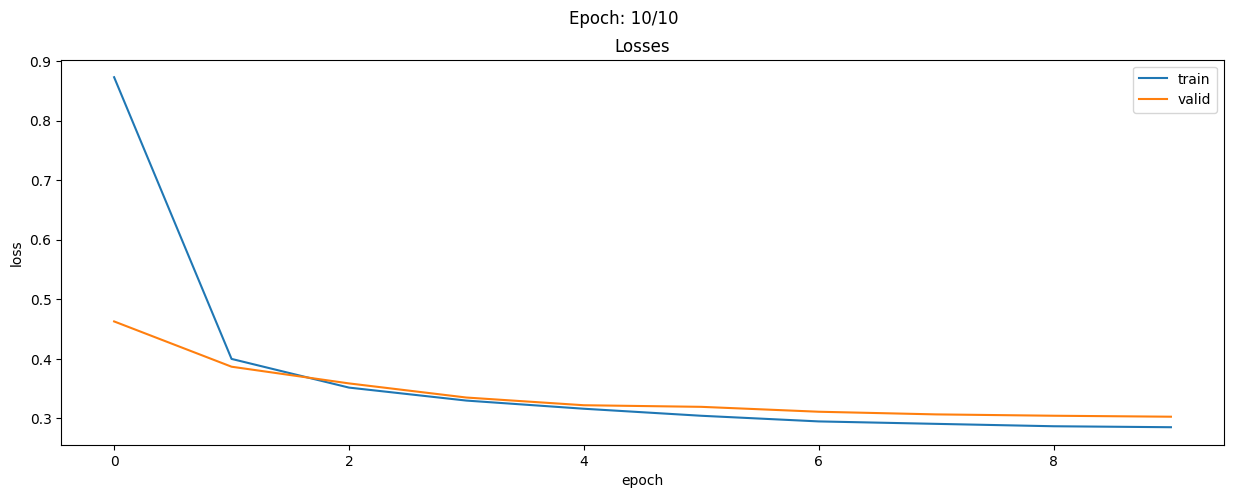

In [19]:
epochs = 10

projectors_es_ro = {
    'source': ProjectionHead().to(device),
    'target': ProjectionHead().to(device)
}

optimizers_es_ro = {
    'source': torch.optim.AdamW(projectors_es_ro['source'].parameters(), lr=1e-2),
    'target': torch.optim.AdamW(projectors_es_ro['target'].parameters(), lr=1e-2)
}

schedulers_es_ro = {
    'source': torch.optim.lr_scheduler.CosineAnnealingLR(optimizers_es_ro['source'], epochs),
    'target': torch.optim.lr_scheduler.CosineAnnealingLR(optimizers_es_ro['target'], epochs)
}

criterion = InfoNCELoss()

history = fit(projectors_es_ro, optimizers_es_ro, criterion, schedulers_es_ro, es_train_loader, es_valid_loader, device, epochs)

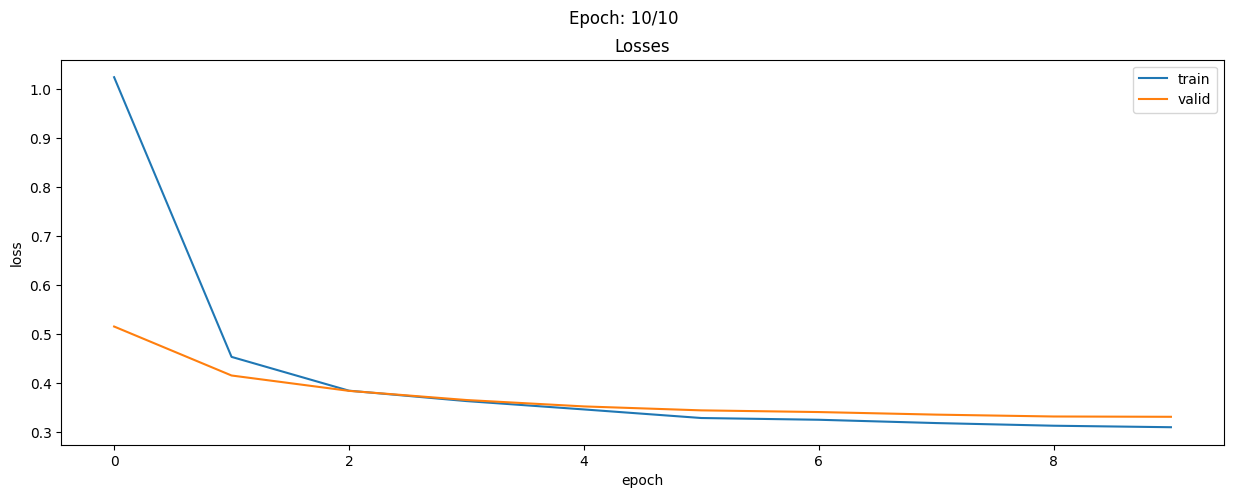

In [20]:
epochs = 10

projectors_pt_ro = {
    'source': ProjectionHead().to(device),
    'target': ProjectionHead().to(device)
}

optimizers_pt_ro = {
    'source': torch.optim.AdamW(projectors_pt_ro['source'].parameters(), lr=1e-2),
    'target': torch.optim.AdamW(projectors_pt_ro['target'].parameters(), lr=1e-2)
}

schedulers_pt_ro = {
    'source': torch.optim.lr_scheduler.CosineAnnealingLR(optimizers_pt_ro['source'], epochs),
    'target': torch.optim.lr_scheduler.CosineAnnealingLR(optimizers_pt_ro['target'], epochs)
}

criterion = InfoNCELoss()

history = fit(projectors_pt_ro, optimizers_pt_ro, criterion, schedulers_pt_ro, pt_train_loader, pt_valid_loader, device, epochs)

In [21]:
@torch.no_grad()
def get_projections(projector, embeddings, batch_size=32):
    projections = []
    for i in tqdm(range(0, len(embeddings), batch_size)):
        portion = torch.tensor(embeddings[i:min(len(embeddings), i+batch_size)])
        portion = portion.to(device)
        portion_proj = projector(portion)
        portion_proj = portion_proj.cpu().numpy()
        projections.append(portion_proj)
    projections = np.concatenate(projections)
    return projections

test_projections_es = get_projections(projectors_es_ro['source'], test_embeddings[es_indices_test])
test_projections_pt = get_projections(projectors_pt_ro['source'], test_embeddings[pt_indices_test])

corpus_projections_for_es = get_projections(projectors_es_ro['target'], corpus_embeddings)
corpus_projections_for_pt = get_projections(projectors_pt_ro['target'], corpus_embeddings)

test_projections_es.shape, test_projections_pt.shape, corpus_projections_for_es.shape, corpus_projections_for_pt.shape

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/469 [00:00<?, ?it/s]

((877, 256), (623, 256), (15000, 256), (15000, 256))

In [22]:
sim_test_es = np_cosine_similarity(test_projections_es, corpus_projections_for_es)
sim_test_pt = np_cosine_similarity(test_projections_pt, corpus_projections_for_pt)

sim_test_es.shape, sim_test_pt.shape

((877, 15000), (623, 15000))

In [23]:
chosen_es = sim_test_es.argmax(axis=1)
chosen_pt = sim_test_pt.argmax(axis=1)

chosen_es.shape, chosen_pt.shape

((877,), (623,))

In [24]:
subm = pd.DataFrame({
    'subtaskID': 1,
    'datapointID': test['query_id'],
    'answer': 1
})
subm.iloc[es_indices_test, 2] = chosen_es
subm.iloc[pt_indices_test, 2] = chosen_pt
subm['answer'] = subm['answer'].map(lambda x: f'doc_{x+1:05}')

subm.to_csv("submission.csv", index=False)
subm.head()

,subtaskID,datapointID,answer
0,1,q_test_00000,doc_00281
1,1,q_test_00001,doc_01601
2,1,q_test_00002,doc_00995
3,1,q_test_00003,doc_00870
4,1,q_test_00004,doc_00074
